Evaluation between TF-IDF, BERT and PUBMEDBERT Models

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# TF-IDF + SVM
tfidf_df = pd.read_csv("/content/tfidf_svm_predictions.csv")

# BERT + SVM
bert_df = pd.read_csv("/content/bert_svm_predictions.csv")

# PubMedBERT + SVM
pubmedbert_df = pd.read_csv("/content/pubmert_svm_predictions.csv")

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    print("=" * 50)
    print(f"MODEL: {model_name}")
    print("=" * 50)

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1
    }

In [ ]:
results = []

# TF-IDF
results.append(
    evaluate_model(
        "TF-IDF + SVM",
        tfidf_df["true_label"],
        tfidf_df["pred_label"]
    )
)

# BERT
results.append(
    evaluate_model(
        "BERT + SVM",
        bert_df["true_label"],
        bert_df["pred_label"]
    )
)

# PubMedBERT
results.append(
    evaluate_model(
        "PubMedBERT + SVM",
        pubmedbert_df["true_label"],
        pubmedbert_df["pred_label"]
    )
)

MODEL: TF-IDF + SVM
Accuracy: 0.5450
Macro F1: 0.3745
Weighted F1: 0.4924

Classification Report:

              precision    recall  f1-score   support

       maybe       0.50      0.09      0.15        22
          no       0.37      0.22      0.28        68
         yes       0.59      0.84      0.69       110

    accuracy                           0.55       200
   macro avg       0.49      0.38      0.37       200
weighted avg       0.51      0.55      0.49       200

MODEL: BERT + SVM
Accuracy: 0.5750
Macro F1: 0.4200
Weighted F1: 0.5827

Classification Report:

              precision    recall  f1-score   support

       maybe       0.05      0.07      0.06        15
          no       0.51      0.54      0.52        63
         yes       0.70      0.66      0.68       122

    accuracy                           0.57       200
   macro avg       0.42      0.42      0.42       200
weighted avg       0.59      0.57      0.58       200

MODEL: PubMedBERT + SVM
Accuracy: 0.5650
M

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Macro_F1,Weighted_F1
0,TF-IDF + SVM,0.545,0.374472,0.492388
1,BERT + SVM,0.575,0.419956,0.582740
2,PubMedBERT + SVM,0.565,0.440872,0.577091


In [ ]:
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results saved.")

Results saved.


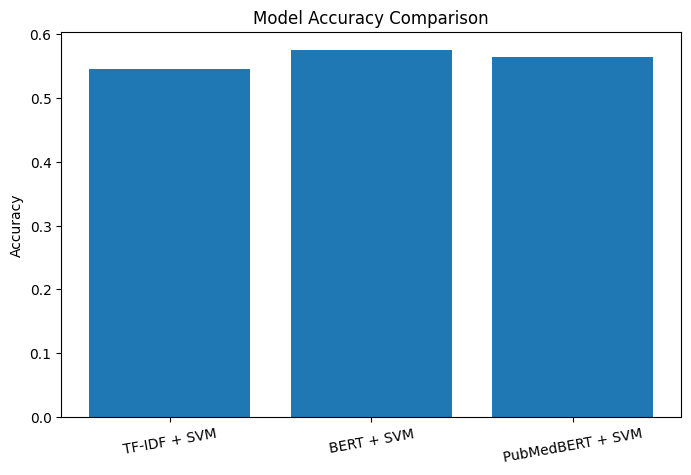

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=10)

plt.show()

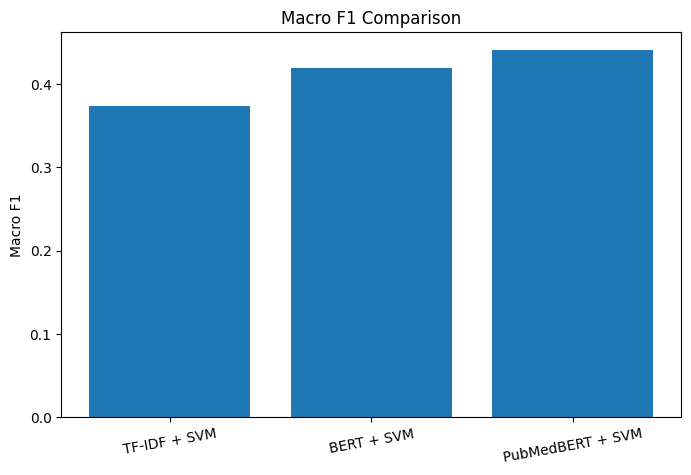

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Macro_F1"]
)

plt.ylabel("Macro F1")
plt.title("Macro F1 Comparison")

plt.xticks(rotation=10)

plt.show()

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

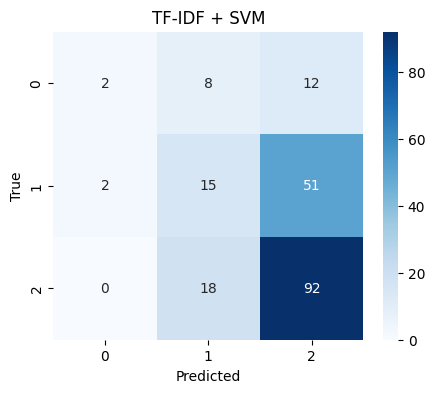

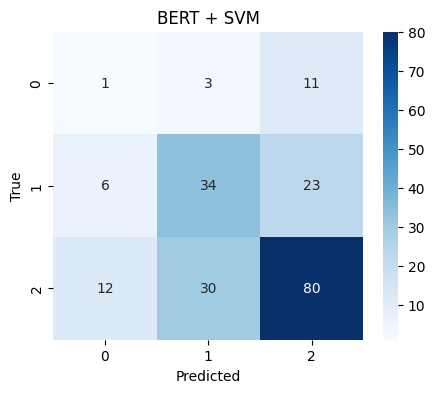

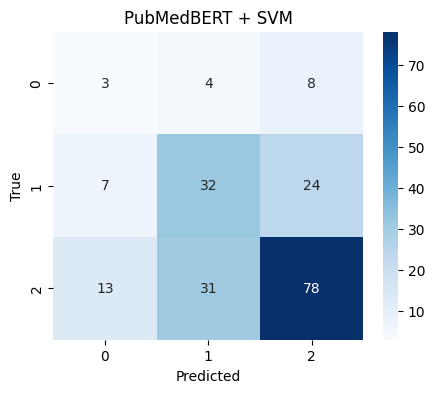

In [ ]:
plot_confusion_matrix(
    tfidf_df["true_label"],
    tfidf_df["pred_label"],
    "TF-IDF + SVM"
)

plot_confusion_matrix(
    bert_df["true_label"],
    bert_df["pred_label"],
    "BERT + SVM"
)

plot_confusion_matrix(
    pubmedbert_df["true_label"],
    pubmedbert_df["pred_label"],
    "PubMedBERT + SVM"
)

In [ ]:
def get_errors(df):

    errors = df[
        df["true_label"] != df["pred_label"]
    ]

    return errors

In [ ]:
tfidf_errors = get_errors(tfidf_df)

tfidf_errors.head()

,true_label,pred_label
1,yes,no
4,no,yes
5,no,yes
8,no,yes
9,no,yes


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar(y_true, pred1, pred2):

    table = [[0, 0], [0, 0]]

    for i in range(len(y_true)):

        correct1 = pred1[i] == y_true[i]
        correct2 = pred2[i] == y_true[i]

        if correct1 and correct2:
            table[0][0] += 1

        elif correct1 and not correct2:
            table[0][1] += 1

        elif not correct1 and correct2:
            table[1][0] += 1

        else:
            table[1][1] += 1

    result = mcnemar(table, exact=True)

    print("P-value:", result.pvalue)

In [ ]:
run_mcnemar(
    list(pubmedbert_df["true_label"]),
    list(pubmedbert_df["pred_label"]),
    list(bert_df["pred_label"])
)

P-value: 0.9187780353645374


In [ ]:
print(results_df.sort_values(
    by="Macro_F1",
    ascending=False
))

              Model  Accuracy  Macro_F1  Weighted_F1
2  PubMedBERT + SVM     0.565  0.440872     0.577091
1        BERT + SVM     0.575  0.419956     0.582740
0      TF-IDF + SVM     0.545  0.374472     0.492388
